In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from dotenv import load_dotenv
import pickle

from torchvision import transforms
from torchvision.datasets import ImageFolder

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from PIL import Image

In [2]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [3]:
import warnings
warnings.filterwarnings('ignore')

**TO ACCESS DATA IN COLLAB**

In [4]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset/

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset/versions/
License(s): copyright-authors
100% 2.70G/2.70G [00:37<00:00, 78.3MB/s]



In [5]:
import zipfile
with zipfile.ZipFile('new-plant-diseases-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [6]:
TRAIN_DIR = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
VALID_DIR = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'
TEST_DIR = '/content/test/test'

**PRE INFO**

In [ ]:
load_dotenv()

TRAIN_DIR = os.getenv("train_folder")
TEST_DIR = os.getenv("test_folder")
VALID_DIR = os.getenv("valid_folder")

**TRANSFORMS and DATASET, DATALOADER**

In [7]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

**TRAIN AND VAL BLOCKS**

In [12]:
def train_block(model, train_dataloader, criterion, optimizer, device):
  model.to(device)
  model.train()

  total_batch_loss = 0.0
  correctly_predicted = 0
  total = 0

  for images, labels in train_dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    total_batch_loss += loss.item()
    total += len(labels)
    _,predicted = torch.max(output, 1)
    correctly_predicted += (predicted == labels).sum().item()

  epoch_loss = total_batch_loss/len(train_dataloader)
  acc = correctly_predicted/total

  return epoch_loss, acc

In [13]:
def val_block(model, valid_dataloader, criterion, device):
  model.to(device)
  model.eval()

  total_batch_loss = 0.0
  correctly_predicted = 0
  total = 0

  with torch.no_grad():

    for images, labels in valid_dataloader:
      images = images.to(device)
      labels = labels.to(device)


      output = model(images)
      loss = criterion(output, labels)

      total_batch_loss += loss.item()
      total += len(labels)
      _,predicted = torch.max(output, 1)
      correctly_predicted += (predicted == labels).sum().item()

    epoch_loss = total_batch_loss/len(valid_dataloader)
    acc = correctly_predicted/total

  return epoch_loss, acc

**PRE TRAINED MODELS**

In [14]:
from torchvision import models

In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

*EFECIENTNET_B0*

In [71]:
enet_weights = models.EfficientNet_B0_Weights.DEFAULT
enet = models.efficientnet_b0(weights=enet_weights)

In [72]:
train_transforms = enet_weights.transforms()
valid_transforms = enet_weights.transforms()

In [73]:
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transforms)
valid_dataset = ImageFolder(VALID_DIR, transform=valid_transforms)

In [74]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [75]:
class_names = train_dataset.classes
num_classes = len(class_names)
num_classes

38

In [76]:
for param in enet.parameters():
    param.requires_grad = False

In [77]:
num_features = enet.classifier[1].in_features

In [78]:
enet.classifier = nn.Sequential(
            nn.Linear(num_features,num_classes)
)

In [79]:
learning_rate = 0.05
epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(enet.parameters(), lr=learning_rate)

In [80]:
train_losses_enet = []
valid_losses_enet = []

train_accs_enet = []
valid_accs_enet = []

In [81]:
for epoch in range(epochs):

  train_loss, train_acc = train_block(enet, train_dataloader, criterion, optimizer, device)
  valid_loss, valid_acc = val_block(enet, valid_dataloader, criterion, device)

  train_losses_enet.append(train_loss)
  train_accs_enet.append(train_acc)

  valid_losses_enet.append(valid_loss)
  valid_accs_enet.append(valid_acc)

  print(f'epoch {epoch+1} train_loss {train_loss} train_acc {train_acc} valid_loss {valid_loss} valid_acc {valid_acc}')

epoch 1 train_loss 1.8275232713901823 train_acc 0.8675865993313892 valid_loss 1.1831293209994642 valid_acc 0.9367175051217846
epoch 2 train_loss 1.7464778535222991 train_acc 0.9193114730777437 valid_loss 1.5019436637974766 valid_acc 0.9386524015479172
epoch 3 train_loss 1.6861509049342276 train_acc 0.9312184365886621 valid_loss 1.453050633776459 valid_acc 0.947074891873435
epoch 4 train_loss 1.6458869876425075 train_acc 0.9392559926026033 valid_loss 1.592222879215425 valid_acc 0.9462781698156157
epoch 5 train_loss 1.6577473176571893 train_acc 0.9422718543281884 valid_loss 1.502574734380492 valid_acc 0.9537332119280674
epoch 6 train_loss 1.626849561143092 train_acc 0.9470090333594139 valid_loss 1.5569805897596019 valid_acc 0.9534486683359891
epoch 7 train_loss 1.6541829454576285 train_acc 0.9484600611707803 valid_loss 1.5461920222529983 valid_acc 0.9576030047803323
epoch 8 train_loss 1.5798683931705606 train_acc 0.9522298883277616 valid_loss 1.7263772795971657 valid_acc 0.95578192579103

In [85]:
torch.save( enet.state_dict() ,'enet.pth')

In [83]:
with open('train_losses_enet.pkl','wb') as f:
  pickle.dump(train_losses_enet, f)

with open('valid_losses_enet.pkl','wb') as f:
  pickle.dump(valid_losses_enet, f)

with open('train_accs_enet.pkl','wb') as f:
  pickle.dump(train_accs_enet, f)

with open('valid_accs_enet.pkl','wb') as f:
  pickle.dump(valid_accs_enet, f)

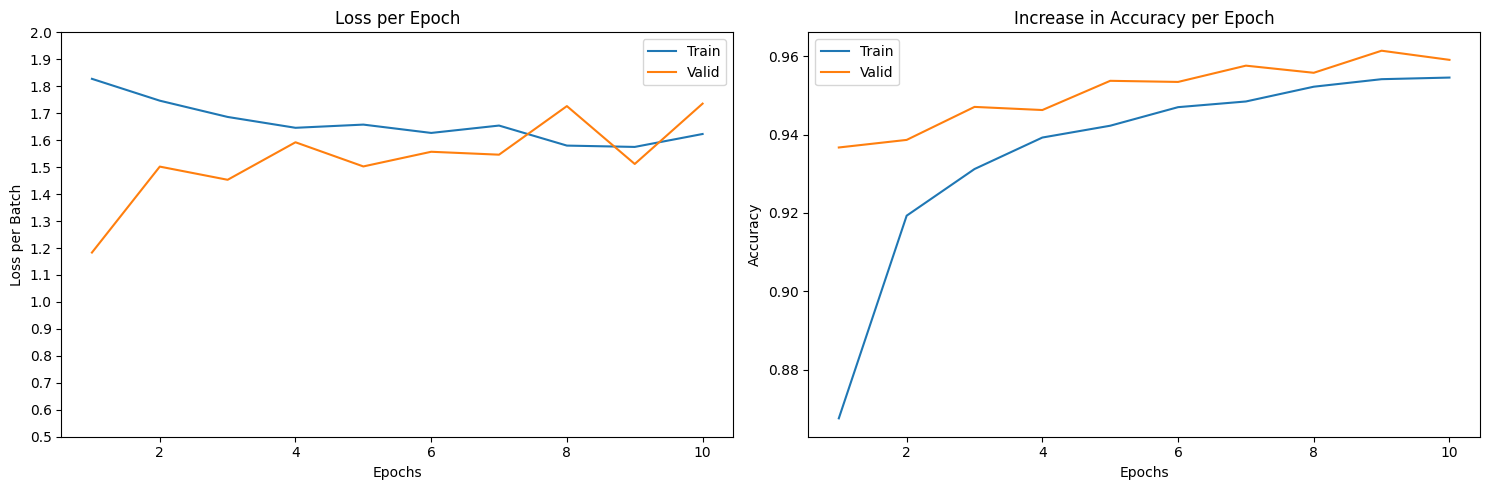

In [84]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(range(1,11),train_losses_enet, label='Train')
plt.plot(range(1,11),valid_losses_enet, label='Valid')
plt.title('Loss per Epoch')
plt.yticks(np.arange(0.5,2.1,0.1))
plt.xlabel('Epochs')
plt.ylabel('Loss per Batch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1,11),train_accs_enet, label='Train')
plt.plot(range(1,11),valid_accs_enet, label='Valid')
plt.title('Increase in Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()